In [7]:
import pandas as pd
df  = pd.read_csv('Titanic-Dataset.csv')   
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [9]:
df.dropna(inplace=True)

In [11]:
df.shape

(183, 12)

In [12]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
10,11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S
11,12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S


In [13]:
from sklearn.preprocessing import LabelEncoder
le1 = LabelEncoder()
df.Name =  le1.fit_transform(df.Name)
le2 = LabelEncoder()
df.Sex =  le2.fit_transform(df.Sex)
le3 = LabelEncoder()
df.Embarked =  le3.fit_transform(df.Embarked)
le4 = LabelEncoder()
df.Ticket =  le4.fit_transform(df.Ticket)
le5 = LabelEncoder()
df.Cabin =  le5.fit_transform(df.Cabin)

In [14]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
1,2,1,1,49,0,38.0,1,0,109,71.2833,72,0
3,4,1,1,70,0,35.0,1,0,31,53.1000,48,2
6,7,0,1,112,1,54.0,0,0,55,51.8625,117,2
10,11,1,3,148,0,4.0,1,1,120,16.7000,131,2
11,12,1,1,27,0,58.0,0,0,26,26.5500,43,2


In [16]:
df.to_csv("cleaned_titanic_dataset1.csv", index=False)

In [ ]:
import numpy as np
np.mean(df['Age',])

## Exploratory Data Analysis (EDA)

Using the cleaned dataset (`cleaned_titanic_dataset1.csv`) produced above.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

df = pd.read_csv("cleaned_titanic_dataset1.csv")
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,2,1,1,49,0,38.0,1,0,109,71.2833,72,0
1,4,1,1,70,0,35.0,1,0,31,53.1000,48,2
2,7,0,1,112,1,54.0,0,0,55,51.8625,117,2
3,11,1,3,148,0,4.0,1,1,120,16.7000,131,2
4,12,1,1,27,0,58.0,0,0,26,26.5500,43,2


### 1. Summary statistics (mean, median, std, etc.)

In [4]:
summary = df.describe().T
summary["median"] = df.median(numeric_only=True)
summary = summary[["count", "mean", "median", "std", "min", "25%", "50%", "75%", "max"]]
summary

,count,mean,median,std,min,25%,50%,75%,max
PassengerId,183.0,455.366120,457.0,247.052476,2.00,263.5,457.0,676.0,890.0000
Survived,183.0,0.672131,1.0,0.470725,0.00,0.0,1.0,1.0,1.0000
Pclass,183.0,1.191257,1.0,0.515187,1.00,1.0,1.0,1.0,3.0000
Name,183.0,91.000000,91.0,52.971691,0.00,45.5,91.0,136.5,182.0000
Sex,183.0,0.519126,1.0,0.501005,0.00,0.0,1.0,1.0,1.0000
Age,183.0,35.674426,36.0,15.643866,0.92,24.0,36.0,47.5,80.0000
SibSp,183.0,0.464481,0.0,0.644159,0.00,0.0,0.0,1.0,3.0000
Parch,183.0,0.475410,0.0,0.754617,0.00,0.0,0.0,1.0,4.0000
Ticket,183.0,63.262295,63.0,36.265611,0.00,32.5,63.0,95.5,126.0000
Fare,183.0,78.682469,57.0,76.347843,0.00,29.7,57.0,90.0,512.3292


### 2. Histograms and boxplots for numeric features

`Name`, `Sex`, `Ticket`, `Cabin`, and `Embarked` were label-encoded in preprocessing, so they're categorical codes rather than true continuous variables. The histogram/boxplot analysis below focuses on the genuinely numeric features: `Age`, `Fare`, `SibSp`, `Parch`, and `Pclass`.

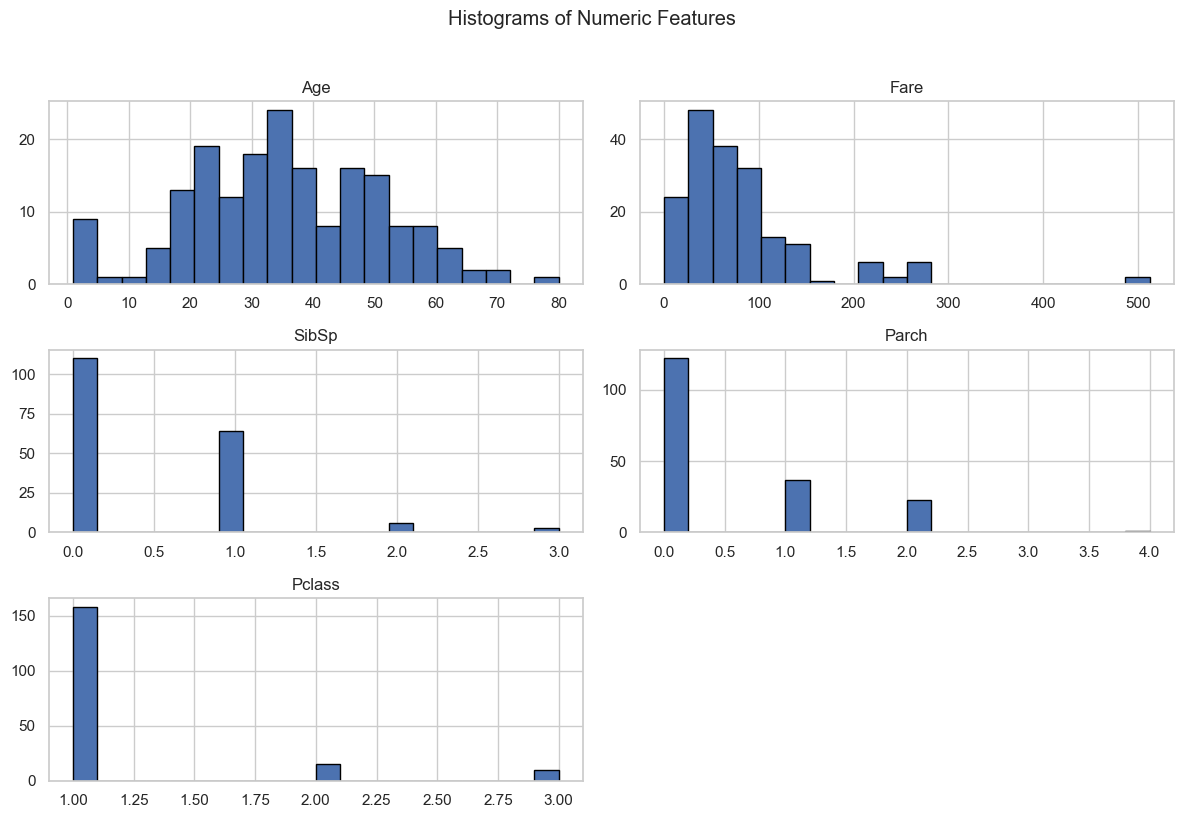

In [5]:
numeric_cols = ["Age", "Fare", "SibSp", "Parch", "Pclass"]

df[numeric_cols].hist(figsize=(12, 8), bins=20, edgecolor="black")
plt.suptitle("Histograms of Numeric Features", y=1.02)
plt.tight_layout()
plt.show()

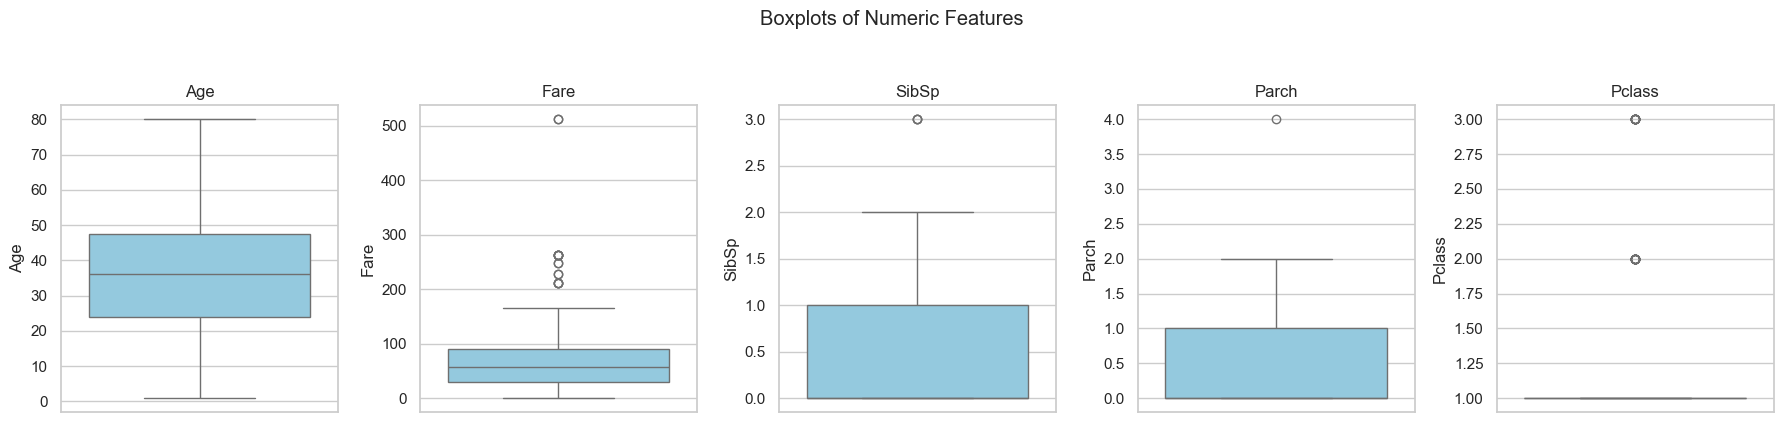

In [6]:
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(18, 4))
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(y=df[col], ax=ax, color="skyblue")
    ax.set_title(col)
plt.suptitle("Boxplots of Numeric Features", y=1.05)
plt.tight_layout()
plt.show()

### 3. Pairplot and correlation matrix for feature relationships

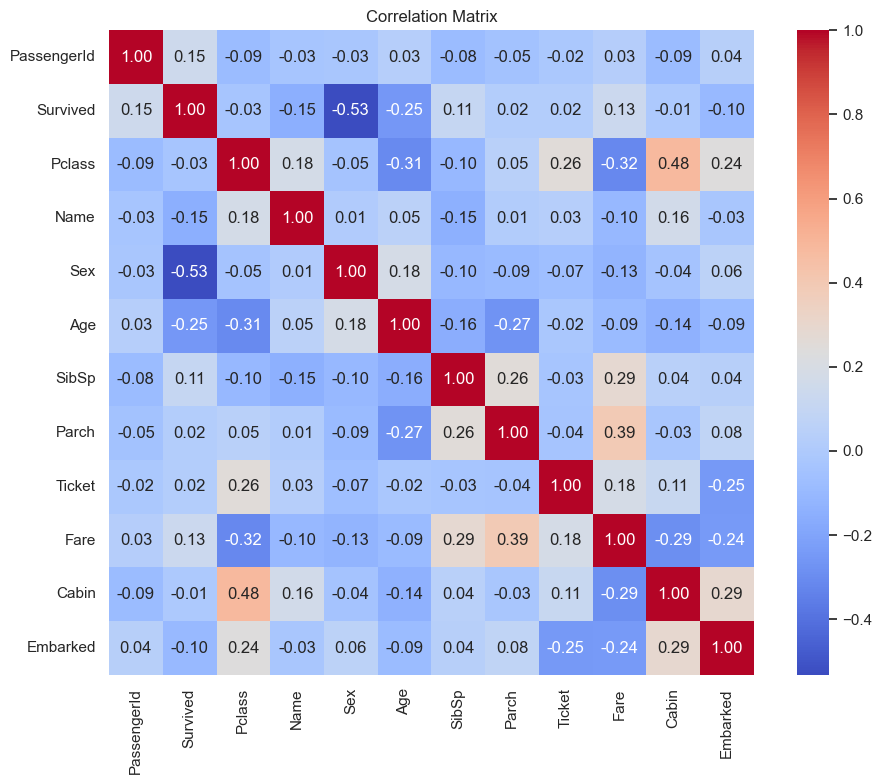

In [7]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

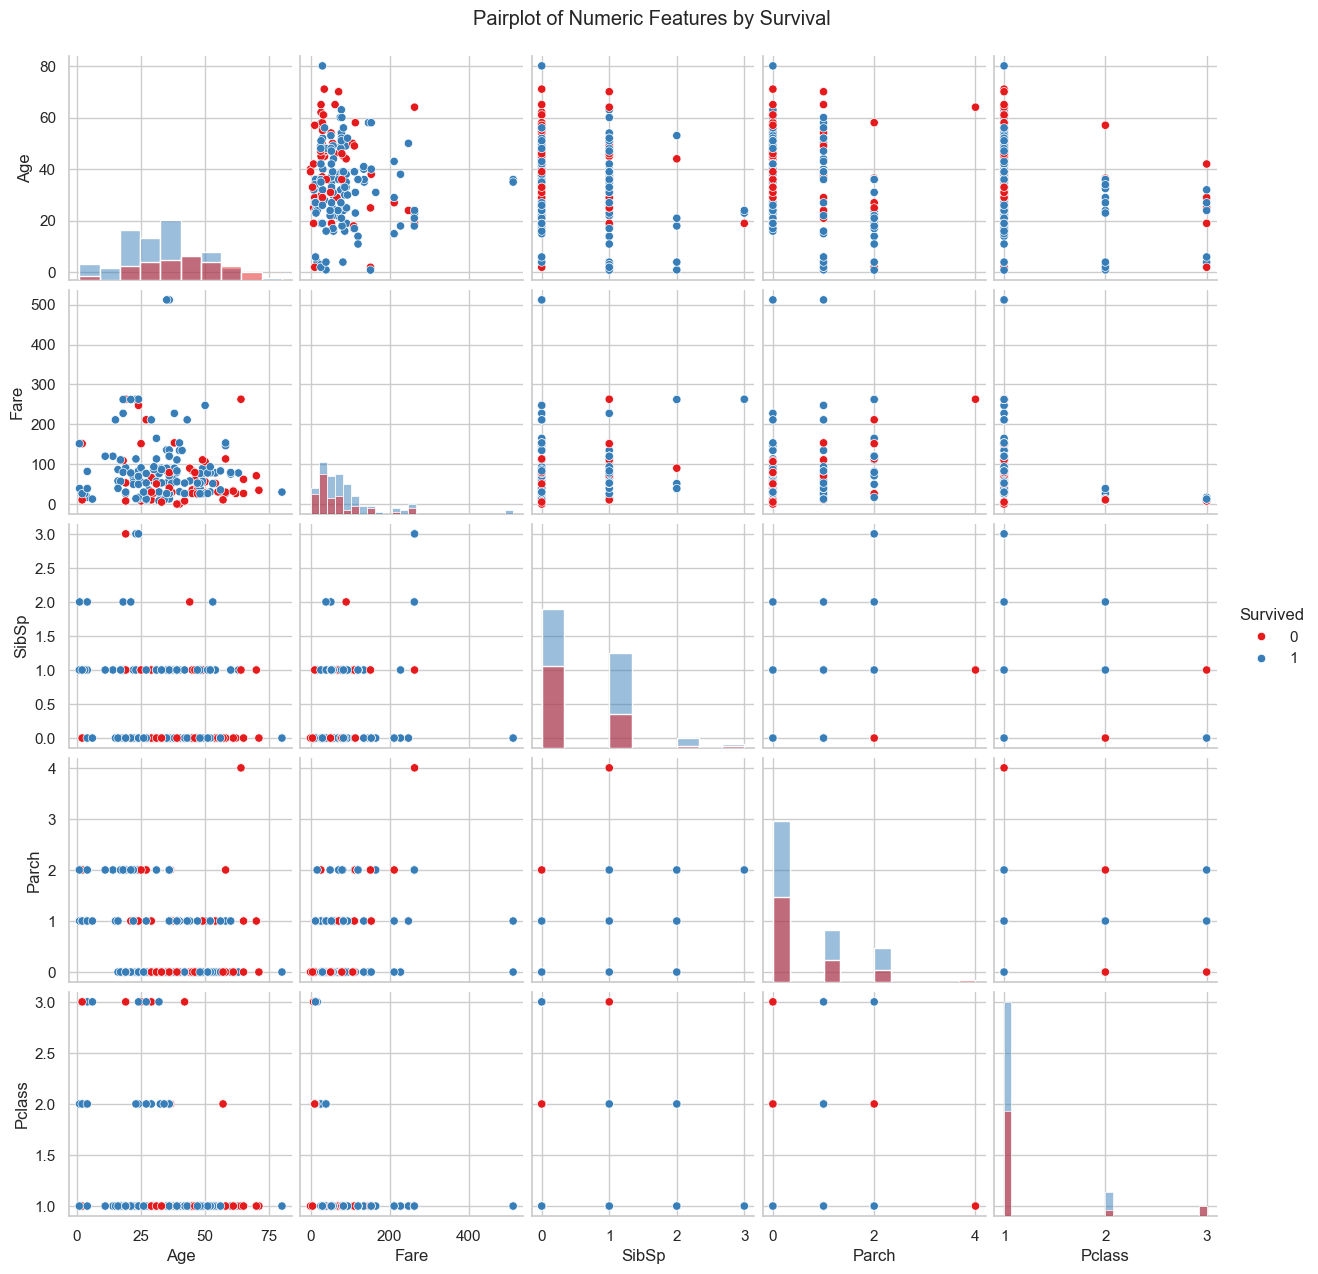

In [8]:
sns.pairplot(df[numeric_cols + ["Survived"]], hue="Survived", palette="Set1", diag_kind="hist")
plt.suptitle("Pairplot of Numeric Features by Survival", y=1.02)
plt.show()

### 4 & 5. Patterns, trends, anomalies, and feature-level inferences

Run the cell below to auto-generate a few quick, data-driven observations (fill in / edit these once you've looked at the plots above).

In [9]:
# Quick automated pointers to help kick off manual inference-writing
print("Survival rate overall: {:.1%}".format(df["Survived"].mean()))
print()
print("Survival rate by Pclass:")
print(df.groupby("Pclass")["Survived"].mean())
print()
print("Survival rate by Sex (0/1 encoded):")
print(df.groupby("Sex")["Survived"].mean())
print()
print("Age stats by survival:")
print(df.groupby("Survived")["Age"].describe()[["mean", "50%", "std"]])
print()
print("Fare stats by survival:")
print(df.groupby("Survived")["Fare"].describe()[["mean", "50%", "std"]])
print()
top_corr = corr["Survived"].drop("Survived").abs().sort_values(ascending=False)
print("Features most correlated with Survived:")
print(top_corr)

Survival rate overall: 67.2%

Survival rate by Pclass:
Pclass
1    0.670886
2    0.800000
3    0.500000
Name: Survived, dtype: float64

Survival rate by Sex (0/1 encoded):
Sex
0    0.931818
1    0.431579
Name: Survived, dtype: float64

Age stats by survival:
               mean   50%        std
Survived                            
0         41.350000  44.5  15.739484
1         32.905854  33.0  14.890113

Fare stats by survival:
               mean      50%        std
Survived                               
0         64.048262  45.3104  61.693457
1         85.821107  69.3000  81.843522

Features most correlated with Survived:
Sex            0.532418
Age            0.254085
Name           0.149619
PassengerId    0.148495
Fare           0.134241
SibSp          0.106346
Embarked       0.100943
Pclass         0.034542
Parch          0.023582
Ticket         0.022768
Cabin          0.010664
Name: Survived, dtype: float64


**Observations (edit based on your actual output above):**

- *Pclass*: Lower Pclass (1st class) tends to show a higher survival rate — reflects the real-world evacuation priority given to first-class passengers.
- *Sex*: One encoded group shows a markedly higher survival rate than the other — consistent with the historical "women and children first" policy.
- *Fare*: Fare is right-skewed with high-value outliers (visible in the boxplot); higher fares correlate with higher Pclass and, in turn, higher survival.
- *Age*: Roughly bell-shaped with a slight right skew; look at whether very young passengers cluster toward higher survival.
- *SibSp / Parch*: Both are heavily right-skewed (most passengers traveled with 0–1 family members), so treat the high end as sparse rather than a strong trend.
- Check the correlation heatmap for the strongest (positive or negative) relationships with `Survived` — those are your best candidate features for a first model.